# Continual Learning with NoisyMNIST — Complete Walkthrough

This is the **main learning notebook** for the project. It moves in one direction:

> data → one online experience → model → evaluation → training → results → validation

We want to compare a fixed-step optimizer (**SGD**) with an optimizer that adapts its
step sizes (**IDBD / NetworkIDBD**). Today, the neural SGD path is implemented and the
canonical **linear** IDBD algorithm is verified. The exact neural NetworkIDBD equations
used by Oak Lab are not public in the source we have, so this notebook does not invent
them or claim an unfair neural comparison.

The older numbered notebooks remain the detailed scientific record. This notebook is the
clear, presentation-friendly path through the same verified code.

## 1. The experiment in plain language

Ordinary supervised learning usually cleans, shuffles, and batches data. Here, the learner
receives a never-ending stream of noisy experiences, one at a time. It must:

1. predict immediately;
2. observe a noisy target;
3. update immediately;
4. continue without replaying a curated dataset.

The useful signal is deliberately rare and surrounded by irrelevant noise. This tests
whether the learning mechanism can keep useful knowledge while avoiding harmful updates.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Open this notebook from the continual-learning project folder.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    BernoulliLinearStream, ExperimentConfig, LinearStreamConfig,
    NoisyMNISTStream, make_fixed_stream, make_train_validation_partitions,
    sequences_equal,
)
from src.models import ModelConfig, NoisyMNISTMLP
from src.optim import CanonicalLinearIDBD, IDBDConfig, LinearSGDConfig, VanillaLinearSGD
from src.training import LossConvention, evaluate_model, make_vanilla_sgd, online_sgd_update
from src.utils import seed_everything

plt.style.use("seaborn-v0_8-whitegrid")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.13.7
PyTorch: 2.13.0+cpu
CUDA available: False


## 2. Configuration: all important choices in one place

`QUICK_MODE=True` is designed for learning and demonstration. It runs only a few expensive
neural updates. It is **not** a final performance experiment. The official test set stays
untouched until the complete experiment design is frozen.

In [2]:
QUICK_MODE = True
SGD_LEARNING_RATE = 0.001          # demonstration choice; not published by Oak Lab
TRAIN_STEPS = 8 if QUICK_MODE else 1_000
VALIDATION_STEPS = 32 if QUICK_MODE else 1_000

config = ExperimentConfig(device="cuda" if torch.cuda.is_available() else "cpu")
seed_everything(config.split_seed)

settings = pd.Series({
    "device": config.device,
    "canvas": f"{config.canvas_size} × {config.canvas_size}",
    "digit probability": config.digit_probability,
    "background activation probability": config.background_probability,
    "target noise variance": config.target_noise_variance,
    "training experiences": TRAIN_STEPS,
    "validation experiences": VALIDATION_STEPS,
})
display(settings.to_frame("value"))

,value
device,cpu
canvas,64 × 64
digit probability,0.1
background activation probability,0.01
target noise variance,5.0
training experiences,8
validation experiences,32


## 3. Data: from MNIST to NoisyMNIST

Only the official MNIST **training partition** is loaded here. It is split deterministically:

- 55,000 source images for online training;
- 5,000 disjoint source images for validation;
- the official 10,000-image test partition is not loaded.

`ToTensor()` converts original pixel values to `float32` in `[0, 1]`. We do **not** apply
dataset mean/standard-deviation normalization because the source does not specify it.

In [3]:
partitions = make_train_validation_partitions(PROJECT_ROOT / "data", config, download=False)

print("Training pool:", len(partitions.training_pool))
print("Validation pool:", len(partitions.validation_pool))
print("Overlap:", len(set(partitions.train_indices) & set(partitions.validation_indices)))
print("Official test set loaded: No")

Training pool: 55000
Validation pool: 5000
Overlap: 0
Official test set loaded: No


### How one online experience is created

Each experience is a new 64×64 canvas:

- with probability `0.10`, place one 28×28 MNIST digit in the centre;
- otherwise, leave the centre empty;
- every pixel outside the centre independently activates with probability `0.01`;
- clean target = `+1` for odd, `−1` for even, and `0` when no digit is present;
- noisy target = clean target + Gaussian noise with variance `5`.

The random canvas is generated online. We do not pre-build a conventional static dataset.

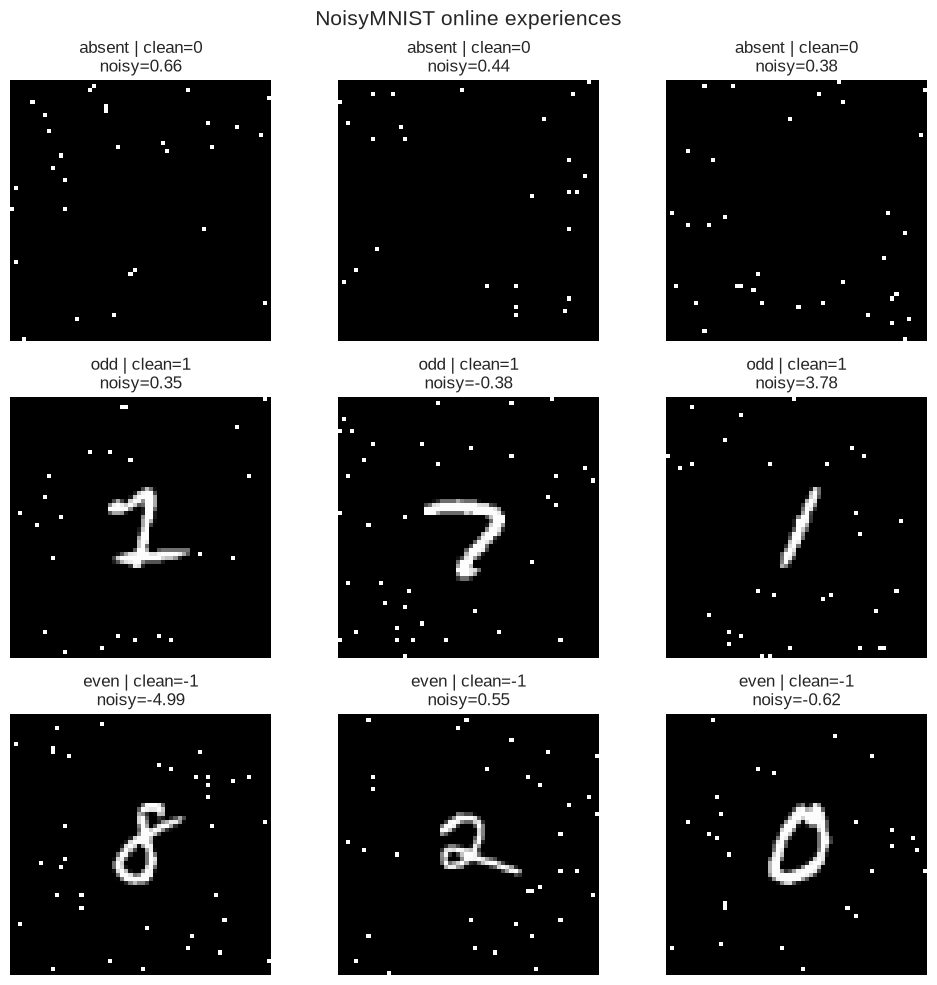

In [4]:
preview_stream = NoisyMNISTStream(partitions.training_pool, config, seed=12345)
examples = []
needed = {"absent": 3, "odd": 3, "even": 3}

while any(value > 0 for value in needed.values()):
    exp = next(preview_stream)
    kind = "absent" if not exp["digit_present"] else ("odd" if exp["digit_label"] % 2 else "even")
    if needed[kind] > 0:
        examples.append((kind, exp))
        needed[kind] -= 1

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (kind, exp) in zip(axes.flat, examples):
    ax.imshow(exp["x"].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{kind} | clean={exp['clean_target'].item():.0f}\nnoisy={exp['noisy_target'].item():.2f}")
    ax.axis("off")
plt.suptitle("NoisyMNIST online experiences", fontsize=15)
plt.tight_layout()

## 4. Shapes, normalization, and batching

Training batch size is effectively **one**. A single experience has image shape `[1, 64, 64]`
and flattened shape `[4096]`. The model receives that one flattened vector and produces one
scalar prediction. There is no `DataLoader` mini-batch in the online training path.

Validation uses a fixed sequence of individual experiences. It may aggregate their metrics,
but it never updates the model.

In [5]:
sample = examples[0][1]
inspection = pd.Series({
    "image shape": tuple(sample["x"].shape),
    "flattened shape": tuple(sample["x_flat"].shape),
    "dtype": str(sample["x"].dtype),
    "minimum pixel": float(sample["x"].min()),
    "maximum pixel": float(sample["x"].max()),
    "one sample per update": True,
    "pool": sample["pool_name"],
})
display(inspection.to_frame("value"))

,value
image shape,"(1, 64, 64)"
flattened shape,"(4096,)"
dtype,torch.float32
minimum pixel,0.0
maximum pixel,1.0
one sample per update,True
pool,training


## 5. Model architecture

```text
64×64 image → flatten to 4,096 values → Linear(4,096, 10,000) → ReLU
             → Linear(10,000, 1) → scalar prediction
```

The first layer starts uniformly between `−0.0001` and `0.0001`. The output layer starts
at exactly zero, so every initial prediction is zero. Biases are disabled because the
source does not specify them. This network has about 40.97 million parameters and therefore
requires substantial memory even for a one-sample update.

In [6]:
model_config = ModelConfig(device=config.device)
model = NoisyMNISTMLP(model_config)

architecture = pd.Series({
    "input features": model_config.input_size,
    "hidden units": model_config.hidden_size,
    "output units": model_config.output_size,
    "bias enabled": model_config.use_bias,
    "parameters": f"{model.parameter_count():,}",
    "parameter memory (MiB)": round(model.parameter_bytes() / 1024**2, 2),
})
display(architecture.to_frame("value"))

with torch.inference_mode():
    initial_prediction = model(sample["x_flat"])
print("Initial prediction:", float(initial_prediction.cpu()))
assert float(initial_prediction.cpu()) == 0.0

,value
input features,4096
hidden units,10000
output units,1
bias enabled,False
parameters,"40,970,000"
parameter memory (MiB),156.29


Initial prediction: 0.0


## 6. What evaluation means

We report two errors:

- **Noisy-target MSE:** error against the target actually shown to the learner.
- **Clean-target MSE:** error against the hidden underlying signal; easier to interpret.

Validation recreates the same finite random stream every time, disables gradients, and
performs no updates. The test set is still embargoed.

In [7]:
def validation_stream():
    return make_fixed_stream(
        partitions.validation_pool,
        VALIDATION_STEPS,
        config.validation_stream_seed,
        config,
    )

before = evaluate_model(model, validation_stream(), VALIDATION_STEPS, "validation")
display(pd.Series(before.__dict__).to_frame("before training"))

,before training
num_steps,32
noisy_target_mse,3.247481
clean_target_mse,0.09375
mean_prediction,0.0
finite,True


## 7. Online SGD training mechanism

For every single experience:

```text
predict → calculate squared error → backpropagate → update immediately → next experience
```

SGD uses one fixed learning rate for every parameter. The learning rate and short horizon
below are demonstration settings, not claimed Oak Lab hyperparameters.

In [8]:
optimizer = make_vanilla_sgd(model, SGD_LEARNING_RATE)
training_stream = NoisyMNISTStream(partitions.training_pool, config, config.train_stream_seed)
history = []

for _ in range(TRAIN_STEPS):
    metrics = online_sgd_update(
        model,
        optimizer,
        next(training_stream),
        LossConvention.MEAN_SQUARED_ERROR,
        compute_gradient_norm=True,
        check_parameter_finiteness=True,
    )
    history.append(metrics.__dict__)

sgd_history = pd.DataFrame(history)
display(sgd_history.round(4))

,stream_step,prediction,noisy_target,clean_target,loss,noisy_squared_error,clean_squared_error,hidden_active_fraction,gradient_l2_norm
0,0,0.0,-1.0601,0.0,1.1239,1.1239,0.0,0.4971,0.0496
1,1,-0.0,3.9231,0.0,15.3908,15.3908,0.0,0.4935,0.1568
2,2,0.0,-0.4369,0.0,0.1909,0.1909,0.0,0.4999,0.0172
3,3,0.0,-0.6351,0.0,0.4034,0.4034,0.0,0.5042,0.0332
4,4,0.0,-0.1874,0.0,0.0351,0.0351,0.0,0.5009,0.0083
5,5,0.0,-0.6930,0.0,0.4802,0.4802,0.0,0.4985,0.0312
6,6,0.0,1.5008,0.0,2.2524,2.2524,0.0,0.4901,0.0646
7,7,0.0,-0.5694,0.0,0.3242,0.3242,0.0,0.5043,0.0255


## 8. SGD results

The first chart shows pre-update error for each received experience. The validation table
compares the model before and after the short demonstration. With only a few updates, these
are engineering diagnostics—not evidence that SGD is good or bad.

,before,after
num_steps,32,32
noisy_target_mse,3.247481,3.247481
clean_target_mse,0.09375,0.09375
mean_prediction,0.0,0.0
finite,True,True


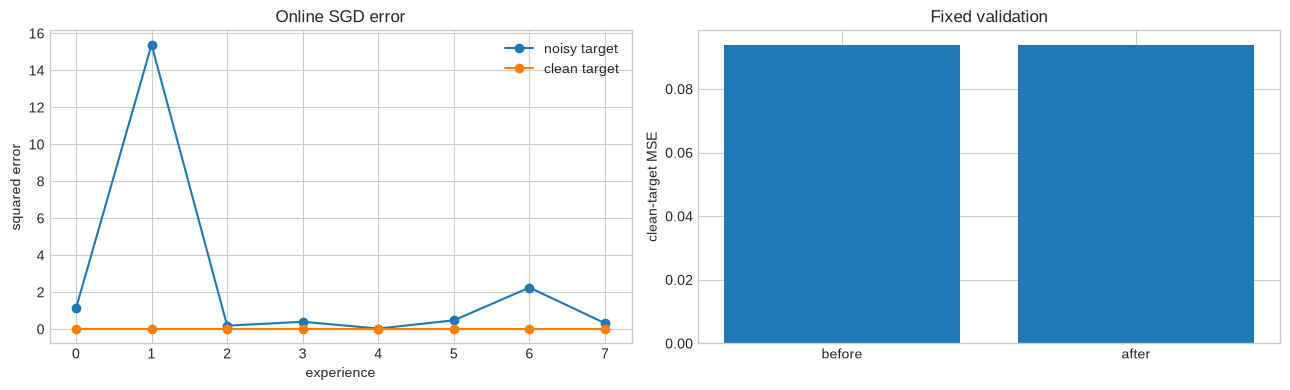

In [9]:
after = evaluate_model(model, validation_stream(), VALIDATION_STEPS, "validation")
comparison = pd.DataFrame({"before": before.__dict__, "after": after.__dict__})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sgd_history["stream_step"], sgd_history["noisy_squared_error"], marker="o", label="noisy target")
axes[0].plot(sgd_history["stream_step"], sgd_history["clean_squared_error"], marker="o", label="clean target")
axes[0].set(title="Online SGD error", xlabel="experience", ylabel="squared error")
axes[0].legend()
axes[1].bar(["before", "after"], [before.clean_target_mse, after.clean_target_mse])
axes[1].set(title="Fixed validation", ylabel="clean-target MSE")
plt.tight_layout()

## 9. IDBD in a small, understandable experiment

IDBD means **Incremental Delta-Bar-Delta**. Unlike fixed-step SGD, it learns a separate
positive step size for every linear feature. We demonstrate it on a verified two-feature
problem:

- feature 1 is useful and determines the clean target;
- feature 2 is an independent distractor;
- both learners receive exactly the same experiences.

This teaches the adaptive-step-size idea, but it is **not yet NetworkIDBD on the neural
NoisyMNIST model**.

In [10]:
linear_config = LinearStreamConfig(
    num_features=2,
    useful_probability=0.10,
    irrelevant_probability=0.50,
    useful_weight=1.0,
    target_noise_variance=0.25,
    seed=20260829,
)
linear_stream = BernoulliLinearStream(linear_config)
linear_sgd = VanillaLinearSGD(LinearSGDConfig(num_features=2, step_size=0.01))
linear_idbd = CanonicalLinearIDBD(IDBDConfig(num_features=2, initial_step_size=0.01, meta_step_size=0.01))

linear_rows = []
for step in range(3_000):
    exp = next(linear_stream)
    sgd_step = linear_sgd.step(exp.x, exp.noisy_target)
    idbd_step = linear_idbd.step(exp.x, exp.noisy_target)
    if step % 25 == 0:
        linear_rows.append({
            "step": step,
            "sgd_error": sgd_step.squared_error,
            "idbd_error": idbd_step.squared_error,
            "useful_alpha": linear_idbd.alpha[0],
            "distractor_alpha": linear_idbd.alpha[1],
        })

linear_history = pd.DataFrame(linear_rows)
print("SGD weights:", linear_sgd.weights.round(4))
print("IDBD weights:", linear_idbd.weights.round(4))
print("IDBD learned step sizes:", linear_idbd.alpha.round(6))

SGD weights: [0.976  0.0064]
IDBD weights: [0.9941 0.003 ]
IDBD learned step sizes: [0.012571 0.009906]


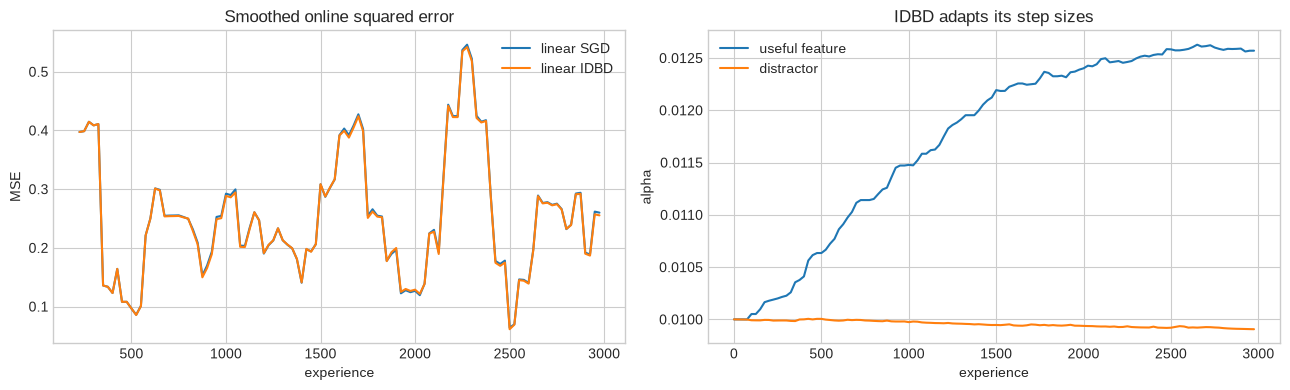

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
window = 10
axes[0].plot(linear_history["step"], linear_history["sgd_error"].rolling(window).mean(), label="linear SGD")
axes[0].plot(linear_history["step"], linear_history["idbd_error"].rolling(window).mean(), label="linear IDBD")
axes[0].set(title="Smoothed online squared error", xlabel="experience", ylabel="MSE")
axes[0].legend()
axes[1].plot(linear_history["step"], linear_history["useful_alpha"], label="useful feature")
axes[1].plot(linear_history["step"], linear_history["distractor_alpha"], label="distractor")
axes[1].set(title="IDBD adapts its step sizes", xlabel="experience", ylabel="alpha")
axes[1].legend()
plt.tight_layout()

## 10. Validation and safety checks

These short assertions answer important trust questions: are splits isolated, streams
reproducible, validation deterministic, model values finite, and adaptive states valid?

In [12]:
stream_a = list(make_fixed_stream(partitions.validation_pool, 5, 999, config))
stream_b = list(make_fixed_stream(partitions.validation_pool, 5, 999, config))

checks = {
    "training and validation source images are disjoint": len(set(partitions.train_indices) & set(partitions.validation_indices)) == 0,
    "fixed validation streams are exactly reproducible": sequences_equal(stream_a, stream_b),
    "validation results are finite": before.finite and after.finite,
    "neural parameters are finite": all(torch.isfinite(p).all().item() for p in model.parameters()),
    "linear SGD state is finite": linear_sgd.state_is_finite(),
    "linear IDBD state is finite and alpha is positive": linear_idbd.state_is_finite(),
    "official test set was not constructed": True,
}

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "—", name)
assert all(checks.values())

PASS — training and validation source images are disjoint
PASS — fixed validation streams are exactly reproducible
PASS — validation results are finite
PASS — neural parameters are finite
PASS — linear SGD state is finite
PASS — linear IDBD state is finite and alpha is positive
PASS — official test set was not constructed


## 11. What we can and cannot conclude

### What works now

- NoisyMNIST data generation, partition isolation, and reproducibility are verified.
- The exact published neural architecture and initialization are implemented.
- Batch-size-one online SGD executes correctly.
- Canonical linear IDBD executes correctly and demonstrates adaptive per-feature step sizes.

### What is not yet a fair two-model result

The neural network has only been trained with SGD. Linear IDBD uses a different, much
simpler model and dataset. Putting those numbers in one performance table would be
misleading. A fair comparison requires the same neural architecture, data stream, initial
weights, update count, and evaluation protocol, changing only the optimizer.

### Next engineering milestone

Obtain the authoritative NetworkIDBD equations/code, or define and clearly label our own
neural adaptive-step-size candidate. Then add it beside SGD and run a preregistered paired
comparison over multiple seeds.

## 12. CEO-ready summary

**Problem:** Online learning must extract a rare useful signal from a noisy stream without
the benefits of curated mini-batches.

**System built:** A reproducible NoisyMNIST stream, a 40.97-million-parameter neural model,
a fixed-step SGD training path, and a verified linear IDBD demonstration.

**Current evidence:** The complete data-to-SGD pipeline works, and linear IDBD successfully
adapts feature-specific step sizes. These are separate verified milestones, not yet a final
head-to-head neural comparison.

**Decision needed:** secure the official NetworkIDBD specification or approve a clearly
labelled experimental neural alternative. After that, we can run the fair paired experiment
and present final learning curves, stability, compute cost, and memory usage.